<a href="https://colab.research.google.com/github/tanvimeshram893-pixel/syntaxhub/blob/main/Credit_card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

Load Dataset

In [56]:
data=pd.read_csv("/content/drive/MyDrive/fraud detection.csv")

In [57]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [58]:
data.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [60]:
data.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [61]:
data.shape

(6362620, 11)

EDA

In [62]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [63]:
print("\nClass Distribution:")
print(data['isFraud'].value_counts())


Class Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64


isFraud
0    99.870918
1     0.129082
Name: isFraud, dtype: float64


<Axes: ylabel='isFraud'>

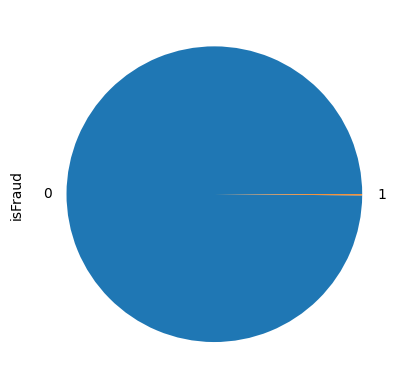

In [64]:
print((data.groupby('isFraud')['isFraud'].count()/data['isFraud'].count())*100)
((data.groupby('isFraud')['isFraud'].count()/data['isFraud'].count())*100).plot.pie()

In [65]:
classes=data['isFraud'].value_counts()
normal_share=classes[0]/data['isFraud'].count()*100
fraud_share=classes[1]/data['isFraud'].count()*100
print(normal_share)
print(fraud_share)

99.87091795518198
0.12908204481801522


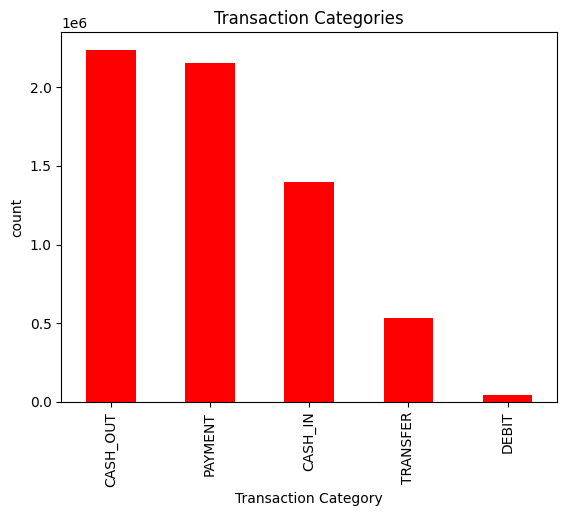

In [66]:
data["type"].value_counts().plot(kind="bar",title="Transaction Categories",color="red")
plt.xlabel("Transaction Category")
plt.ylabel("count")
plt.show()

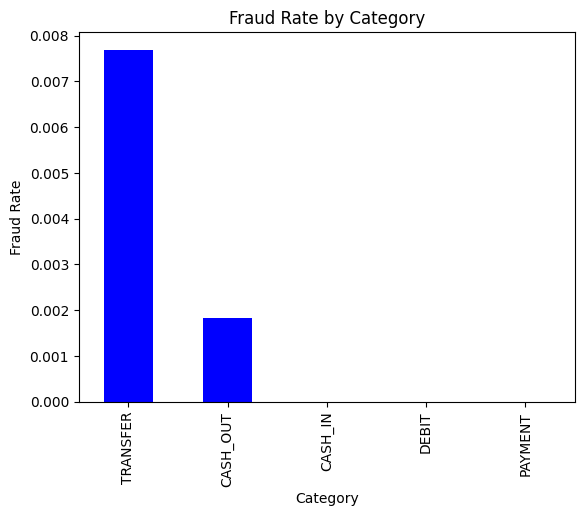

In [67]:
fraud_by_type=data.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate by Category", color="blue")
plt.ylabel("Fraud Rate")
plt.xlabel("Category")
plt.show()

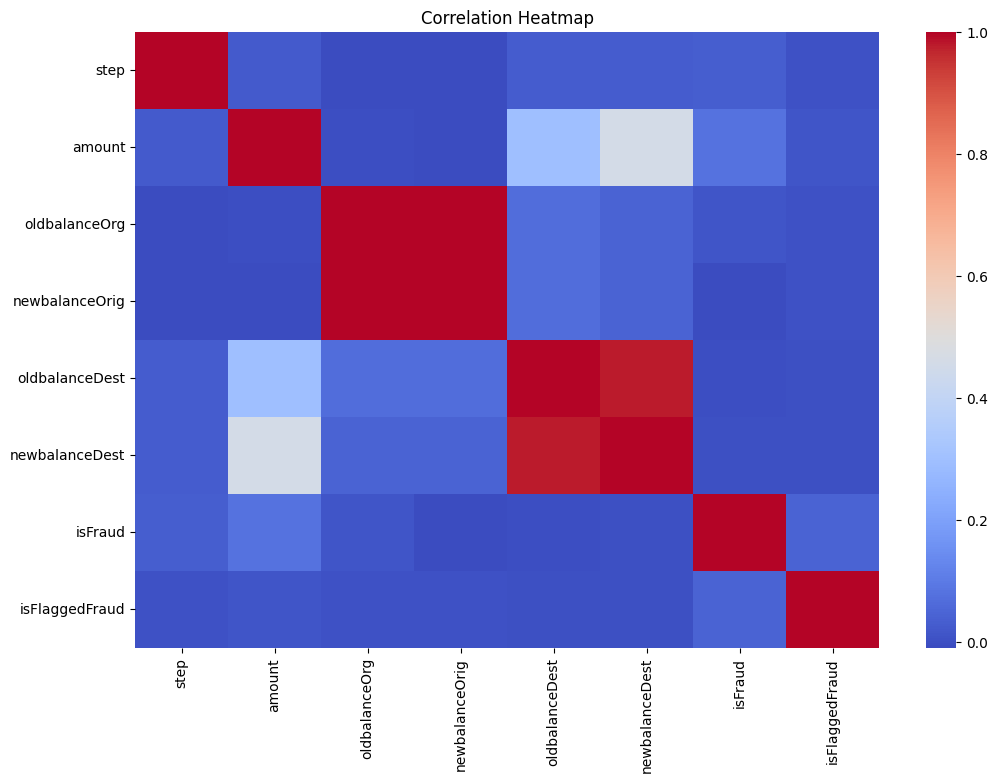

In [68]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(data.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

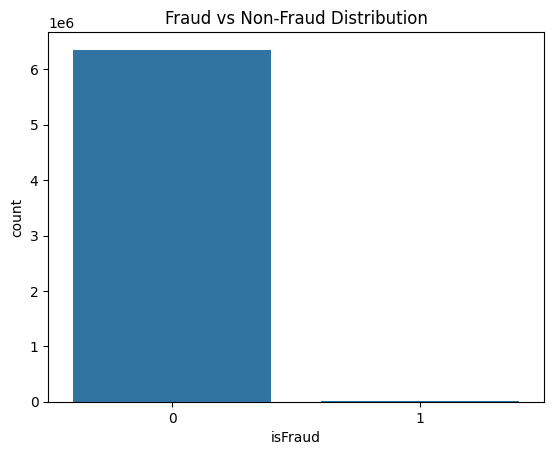

In [69]:
# Class distribution
sns.countplot(x='isFraud', data=data)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

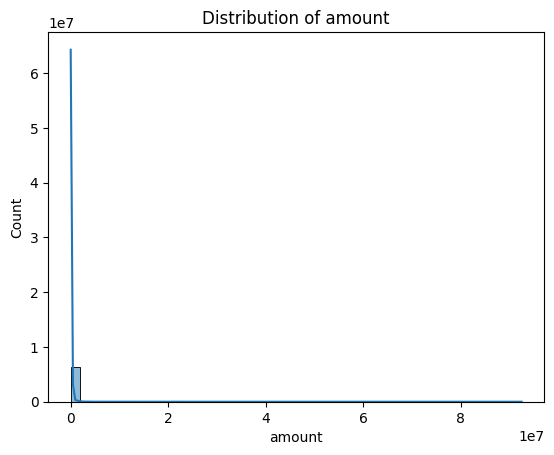

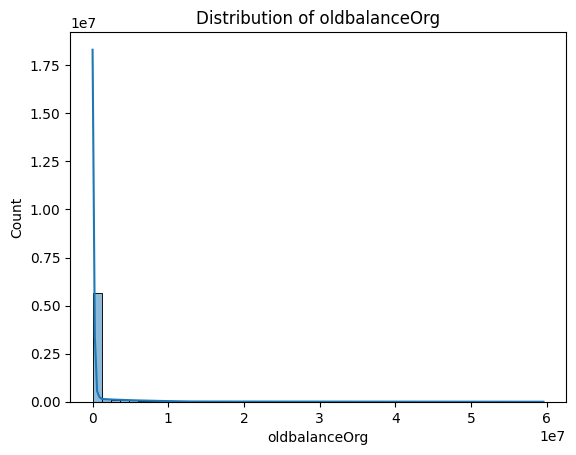

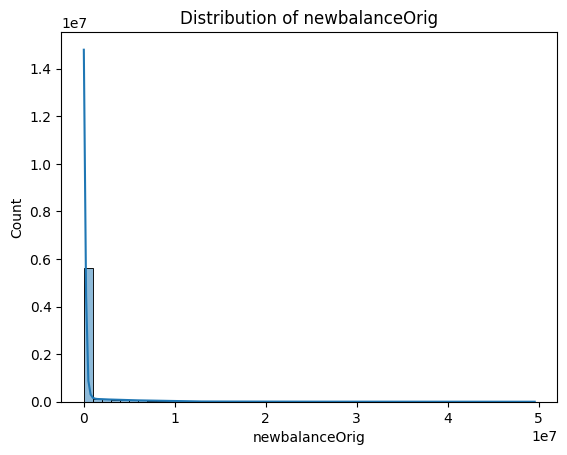

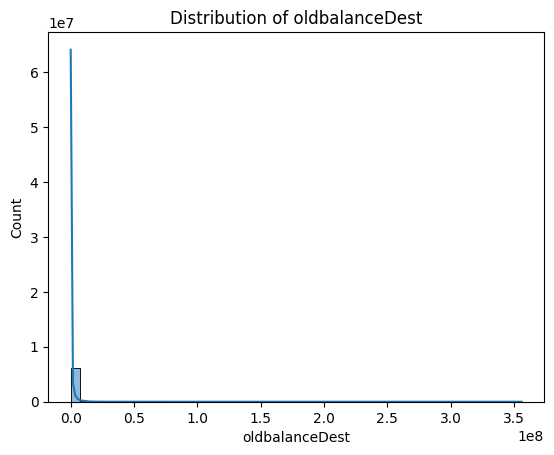

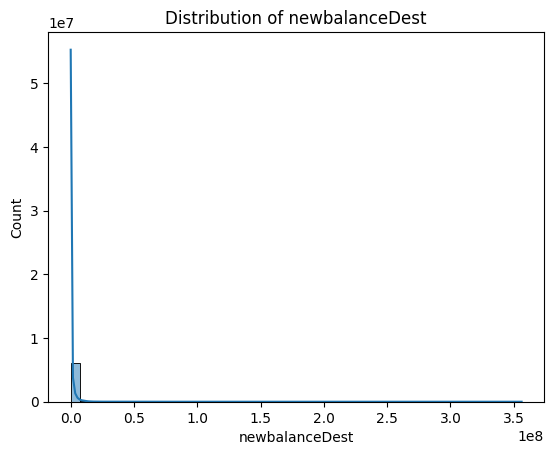

In [70]:
# Distribution of some features
features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for f in features:
    plt.figure()
    sns.histplot(data[f], bins=50, kde=True)
    plt.title(f"Distribution of {f}")
    plt.show()

Feature scaling and cleaning

In [71]:
scaler = StandardScaler()
data['amount'] = scaler.fit_transform(data[['amount']])
print("Amount column scaled successfully.")

Amount column scaled successfully.


split data

In [72]:
X = data.drop('isFraud', axis=1)
y = data['isFraud']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [74]:
print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (5090096, 10)
Testing data size: (1272524, 10)


Handle imbalance using SMOTE

In [75]:
# One-hot encode the 'type' column
X_train_encoded = pd.get_dummies(X_train, columns=['type'], drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=['type'], drop_first=True)

# Drop 'nameOrig' and 'nameDest' columns from X_train_encoded before applying SMOTE
X_train_encoded = X_train_encoded.drop(['nameOrig', 'nameDest'], axis=1)
X_test_encoded = X_test_encoded.drop(['nameOrig', 'nameDest'], axis=1)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_encoded, y_train)

In [76]:
print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts())


After SMOTE:
isFraud
0    5083526
1    5083526
Name: count, dtype: int64


Train machine learning models

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("----------------------------")

In [78]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=50,class_weight='balanced')
model.fit(X_train_res,y_train_res)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=50)

XGBoost model

In [79]:
# Evaluate XGBoost
print("XGBoost Performance")
evaluate_model(xgb, X_test_encoded, y_test)

XGBoost Performance
Accuracy: 0.9976974893990211
Precision: 0.3582911253027967
Recall: 0.9902617163724894
ROC-AUC: 0.9939844093841932
----------------------------


In [80]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:57:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

Make Predictions

In [81]:
y_pred_xgb = xgb.predict(X_test_encoded)
y_prob_xgb = xgb.predict_proba(X_test_encoded)[:,1]

Model evaluation

In [82]:
print("===== XGBoost =====")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

===== XGBoost =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.36      0.99      0.53      1643

    accuracy                           1.00   1272524
   macro avg       0.68      0.99      0.76   1272524
weighted avg       1.00      1.00      1.00   1272524

ROC-AUC Score: 0.999594443875758


Confusion matrix

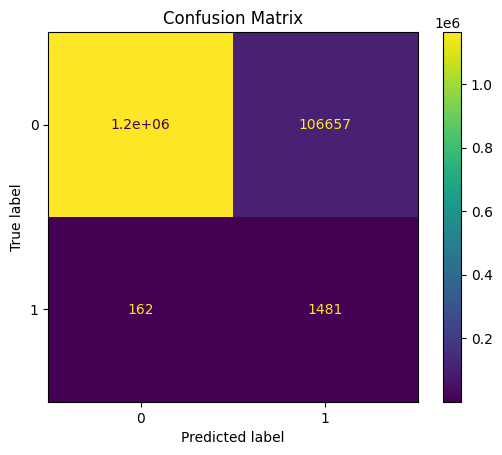

In [83]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test_encoded)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

ROC curve

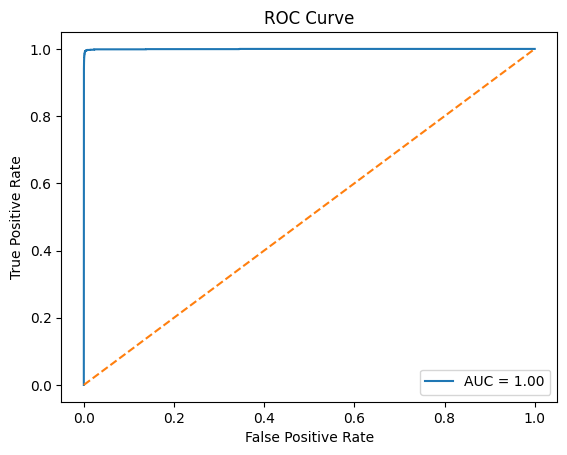

In [84]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Business decision threshold

In [85]:
# Default threshold = 0.5
# Change threshold to increase fraud detection

y_pred_custom = (y_prob_xgb > 0.3).astype(int)

print("===== Custom Threshold (0.3) =====")

===== Custom Threshold (0.3) =====


In [86]:
# Predict probabilities
y_probs = model.predict_proba(X_test_encoded)[:,1]

In [87]:
# Custom threshold
threshold = 0.3
y_pred_custom = (y_probs > threshold).astype(int)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      0.63      0.77   1270881
           1       0.00      0.97      0.01      1643

    accuracy                           0.63   1272524
   macro avg       0.50      0.80      0.39   1272524
weighted avg       1.00      0.63      0.77   1272524



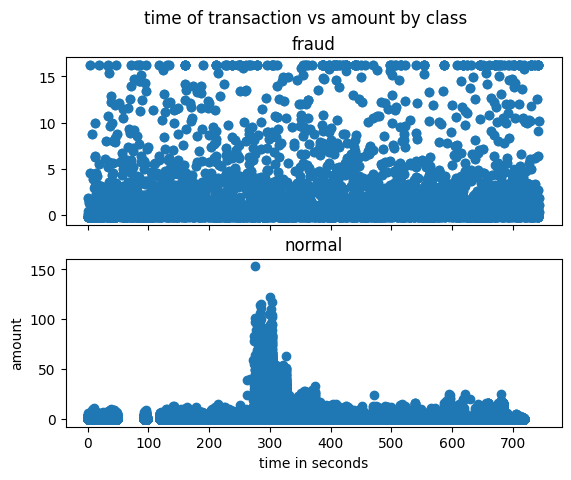

In [88]:
Fraud = data[data['isFraud'] == 1]
normal = data[data['isFraud'] == 0]

f,(ax1,ax2)=plt.subplots(2,1,sharex=True)
f.suptitle('time of transaction vs amount by class')
ax1.scatter(Fraud['step'],Fraud['amount'])
ax1.set_title('fraud')
ax2.scatter(normal['step'],normal['amount'])
ax2.set_title('normal')
plt.xlabel('time in seconds')
plt.ylabel('amount')
plt.show()

In [89]:
import joblib

In [90]:
joblib.dump(xgb,"credit_card_model")

['credit_card_model']